In [ ]:
# !pip install -q "kaleido==0.2.1"

In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy import stats

# Question 2 — Vehicle Depreciation: Age and Mileage

## Research question
How are vehicle age (`Age_08_04`) and mileage (`KM`) related to price (`Price`)?
Are these relationships linear or non-linear, and does the age–price relationship
look different at different mileage levels — or the other way round?

## Analysis plan
1. Scope the data to the three relevant variables and audit their quality.
2. Describe each variable's distribution and quantify its shape.
3. Examine each relationship with price, and test whether it is linear.
4. Separate the overlap between age and mileage.
5. Test whether the mileage effect changes across age levels.
6. Draw conclusions and state what they imply for a future model.

No model is fitted in this notebook. All findings are associations, not causal effects.

## **מגישים**

איתמר חושן


אלעד מאיסי

אריאל קוריצ'ר

In [3]:
# Colab has its own output mechanism; Jupyter and VS Code use plotly_mimetype.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

pio.renderers.default = "colab" if IN_COLAB else "plotly_mimetype+notebook_connected"

# "auto" = interactive, for working inside Colab.
# "png"  = static images. No scripts, no CDN, no notebook-trust requirement.
#          This is the safe choice for submission.
# "html" = interactive and embedded, but the reader must trust the notebook.
SHOW_MODE = "png"

_JS_EMBEDDED = {"done": False}

PNG_SCALE     = 2      # export resolution multiplier: 2 keeps text crisp
DISPLAY_WIDTH = 900    # on-screen width in pixels. Lower this to shrink the figures.

def _no_webgl(fig):
    """Convert WebGL traces to SVG traces. Headless Chrome has no GPU, so
    scattergl cannot be exported to a static image."""
    spec = fig.to_dict()
    for trace in spec.get("data", []):
        if trace.get("type") == "scattergl":
            trace["type"] = "scatter"
    return go.Figure(spec)


def show(fig):
    """Display a Plotly figure reliably across notebook environments."""
    # Respect each figure's own dimensions rather than forcing one size.
    w = int(fig.layout.width  or 1100)
    h = int(fig.layout.height or 560)

    if SHOW_MODE == "png":
        try:
            from IPython.display import Image, display
            png = pio.to_image(_no_webgl(fig), format="png",
                               width=w, height=h, scale=PNG_SCALE)
            # Exported at high resolution, displayed at DISPLAY_WIDTH:
            # sharp on any screen, correctly sized in the notebook.
            display(Image(png, width=DISPLAY_WIDTH,
                          height=int(DISPLAY_WIDTH * h / w)))
            return
        except Exception as err:
            print(f"PNG export failed -> {type(err).__name__}: {err}")
            print("Falling back to HTML for this figure.")

    if SHOW_MODE in ("html", "png"):
        from IPython.display import HTML, display
        embed = not _JS_EMBEDDED["done"]
        _JS_EMBEDDED["done"] = True
        display(HTML(pio.to_html(fig, include_plotlyjs=embed,
                                 full_html=False, default_width="100%")))
        return

    fig.show()

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Shared style for every chart in this notebook.
LAYOUT = dict(template="plotly_white", font=dict(size=13),
              margin=dict(l=70, r=40, t=80, b=60))

# Keep the Excel file in the same folder as the notebook.
DATA_PATH = "Toyota_Corolla_cars.xlsx"
VARS = ["Price", "Age_08_04", "KM"]

raw = pd.read_excel(DATA_PATH)
print(f"Raw file: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Question 2 scope: {VARS}")
raw[VARS].head()

Raw file: 1,436 rows x 39 columns
Question 2 scope: ['Price', 'Age_08_04', 'KM']


,Price,Age_08_04,KM
0,13500,23,46986
1,13750,23,72937
2,13950,24,41711
3,14950,26,48000
4,13750,30,38500


# Part A — Exploratory Data Analysis

## Step 1 — Scope, data quality and distributions

### 1. Scope and data quality

Only `Price`, `Age_08_04` and `KM` are examined; the remaining 36 columns belong to
other research questions. Before looking at relationships, we check the scale of each
variable and whether any recorded value is implausible.

In [4]:
summary = pd.DataFrame({
    "N":       raw[VARS].count(),
    "Missing": raw[VARS].isna().sum(),
    "Mean":    raw[VARS].mean(),
    "Median":  raw[VARS].median(),
    "SD":      raw[VARS].std(),
    "Min":     raw[VARS].min(),
    "Max":     raw[VARS].max(),
})
display(summary.round(1))

print(f"Duplicate rows       : {raw.duplicated().sum()}")
print(f"Duplicate Id values  : {raw['Id'].duplicated().sum()}")
print(f"Total missing values : {int(raw[VARS].isna().sum().sum())}")

,N,Missing,Mean,Median,SD,Min,Max
Price,1436,0,"10,730.80","9,900.00","3,627.00",4350,32500
Age_08_04,1436,0,55.90,61.00,18.60,1,80
KM,1436,0,"68,533.30","63,389.50","37,506.40",1,243000


Duplicate rows       : 0
Duplicate Id values  : 0
Total missing values : 0


### 2. Plausibility checks

A low value is not automatically an error. We therefore inspect each flagged record in
context rather than applying a blanket rule.

In [5]:
# A) Engine size: one implausible value (outside Q2 scope, reported for completeness).
cc_error = raw.loc[raw["CC"] > 2500, ["Id", "Model", "Price", "CC"]]
print("A) Implausible engine size (CC):")
display(cc_error)

# B) Mileage of 1 km is only implausible RELATIVE TO AGE, so we show age alongside it.
km_flag = raw.loc[raw["KM"] <= 1, ["Id", "Price", "Age_08_04", "KM"]].sort_values("Age_08_04")
print(f"B) Records with KM <= 1: {len(km_flag)}")
display(km_flag)

# C) Verso is an MPV (7-seat) body type, not a hatchback or sedan.
verso = raw["Model"].str.contains("VERSO", case=False, na=False)
print(f"C) Verso (MPV) records: {int(verso.sum())}")
display(raw.loc[verso, ["Id", "Model", "Price", "Age_08_04", "KM"]])

A) Implausible engine size (CC):


,Id,Model,Price,CC
80,81,TOYOTA Corolla 1.6 5drs 1 4/5-Doors,18950,16000


B) Records with KM <= 1: 8


,Id,Price,Age_08_04,KM
185,187,18245,1,1
184,186,17795,1,1
109,111,32500,4,1
117,119,17900,7,1
170,172,18245,9,1
169,171,17795,9,1
601,605,7500,50,1
1435,1442,6950,76,1


C) Verso (MPV) records: 5


,Id,Model,Price,Age_08_04,KM
109,111,TOYOTA Corolla VERSO 2.0 D4D SOL (7) BNS MPV,32500,4,1
110,112,TOYOTA Corolla VERSO 2.0 D4D SOL (7) MPV,31000,4,4000
111,113,TOYOTA Corolla VERSO 2.0 D4D SOL (7) MPV,31275,4,1500
112,114,TOYOTA Corolla VERSO 2.0 D4D LINEA SOL MPV,24950,8,13253
113,115,TOYOTA Corolla VERSO 2.0 D4D LINEA SOL MPV,24950,8,13253


In [6]:
df_all = raw.copy()
df_all.loc[df_all["Id"] == 81, "CC"] = 1600            # correct the data-entry error
df_all["is_verso"]   = verso.values                    # structural flag, not an outlier flag
df_all["km_suspect"] = (df_all["KM"] <= 1) & (df_all["Age_08_04"] > 24)

# Analysis sample: Corolla passenger cars only. df_all is kept for sensitivity checks.
df = df_all.loc[~df_all["is_verso"], VARS].reset_index(drop=True)

print(f"Full sample     : {len(df_all):,} cars")
print(f"Verso excluded  : {int(df_all['is_verso'].sum())}")
print(f"Analysis sample : {len(df):,} cars")
print(f"Suspect mileage records retained : {int(df_all['km_suspect'].sum())}")

Full sample     : 1,436 cars
Verso excluded  : 5
Analysis sample : 1,431 cars
Suspect mileage records retained : 2


### Findings

- **1,436 records, no missing values and no duplicates** in the three variables.
  No missing-value treatment is required.
- **One engine-size error:** `Id 81` records `CC = 16,000` for a 1.6-litre Corolla —
  a factor-of-ten typing error, corrected to 1,600. `CC` is not used in Question 2,
  so this does not affect any result below.
- **Eight cars record `KM = 1`.** Six are 1–9 months old, where a near-zero reading is
  plausible. Two are **50 and 76 months old**, where it is not. These two are flagged
  and kept, then re-checked in a sensitivity analysis rather than deleted.
- **Five cars are Verso models.** The Verso is a 7-seat MPV, a different body type and
  market segment from the hatchbacks and sedans that make up the rest of the sample.
  They are excluded on structural grounds — not because their prices are high — which
  defines the study population rather than trimming inconvenient observations.
  Note that `Id 111` is both a Verso and a `KM = 1` record.

The analysis sample is **1,431 Corolla passenger cars**. The full sample is retained
as `df_all` so that every exclusion can be re-tested later.

### 3. Distribution of each variable

We describe each variable on its own before looking at any relationship. Shape matters
here because it determines which summary statistic is honest and which methods stay
valid later.

In [7]:
shape = pd.DataFrame({
    "Mean":          [df[c].mean() for c in VARS],
    "Median":        [df[c].median() for c in VARS],
    "Mean - Median": [df[c].mean() - df[c].median() for c in VARS],
    "Skewness":      [stats.skew(df[c]) for c in VARS],
}, index=VARS)
display(shape.round(2))

,Mean,Median,Mean - Median,Skewness
Price,"10,667.22","9,900.00",767.22,1.46
Age_08_04,56.12,61.00,-4.88,-0.81
KM,"68,750.35","63,500.00","5,250.35",1.03


Histograms and boxplots are shown together: the histogram shows the shape of the
distribution, while the boxplot shows position and flagged extreme values.

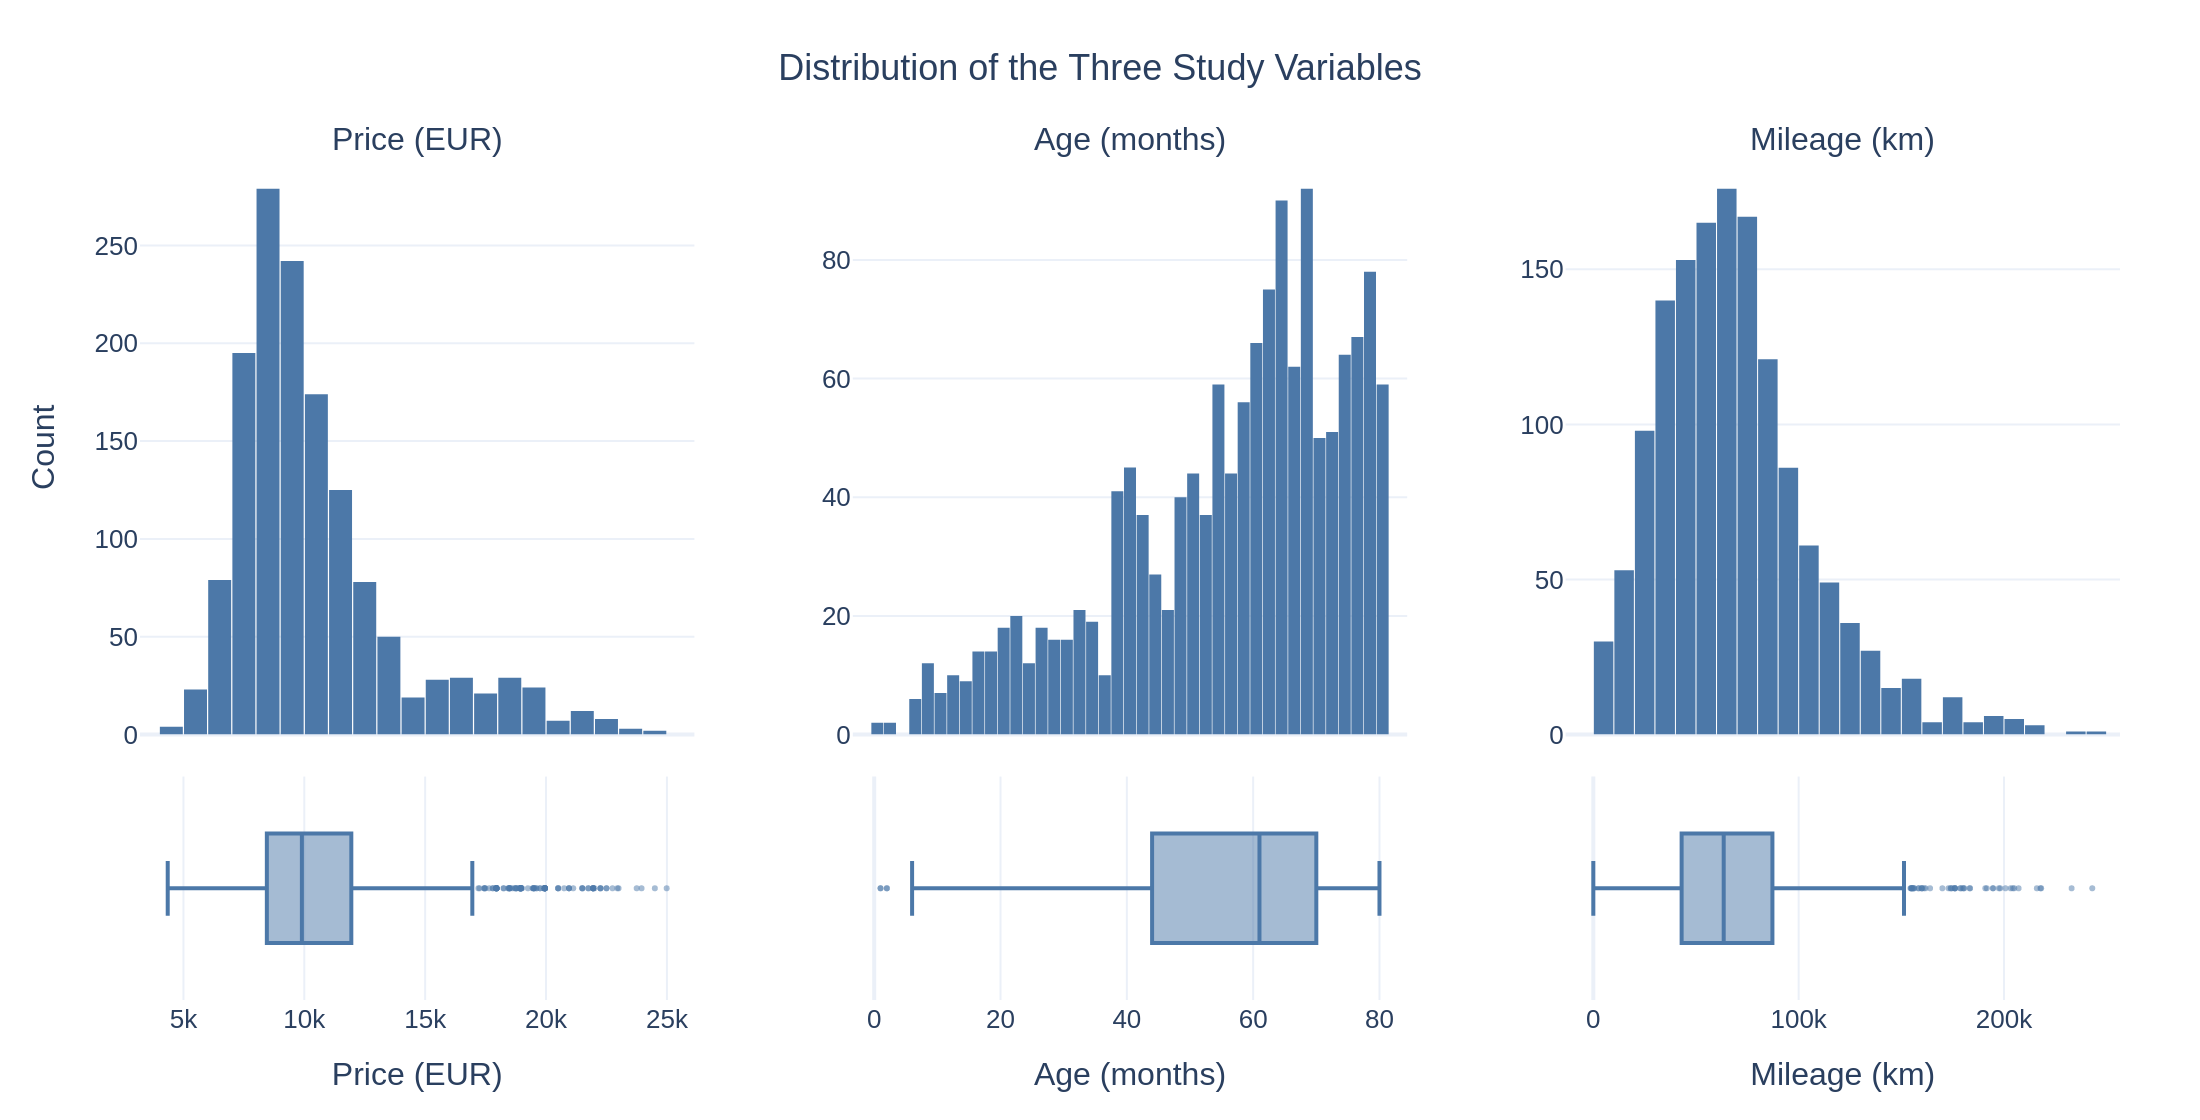

In [8]:
LABELS = {"Price": "Price (EUR)", "Age_08_04": "Age (months)", "KM": "Mileage (km)"}

fig = make_subplots(
    rows=2, cols=3, shared_xaxes=True,
    row_heights=[0.72, 0.28], vertical_spacing=0.05, horizontal_spacing=0.08,
    subplot_titles=[LABELS[c] for c in VARS] + [""] * 3
)

for j, c in enumerate(VARS, start=1):
    fig.add_trace(go.Histogram(x=df[c], nbinsx=40, marker_color="#4C78A8",
                               showlegend=False), row=1, col=j)
    fig.add_trace(go.Box(x=df[c], marker_color="#4C78A8", boxpoints="outliers",
                         marker=dict(size=3, opacity=0.5), name="",
                         showlegend=False), row=2, col=j)
    fig.update_xaxes(title_text=LABELS[c], row=2, col=j)
    fig.update_yaxes(showticklabels=False, row=2, col=j)

fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_layout(**LAYOUT, height=560, width=1100, bargap=0.05,
                  title=dict(text="Distribution of the Three Study Variables",
                             x=0.5, xanchor="center"))
show(fig)

### 4. Extreme values

Extreme values are located using the standard boxplot rule, Q3 + 1.5 x IQR. The rule
identifies candidates for review — it is not a deletion rule. We therefore profile the
flagged records before deciding anything.

In [9]:
def iqr_fences(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

flags = []
for c in VARS:
    lo, hi = iqr_fences(df[c])
    n_lo, n_hi = int((df[c] < lo).sum()), int((df[c] > hi).sum())
    flags.append({"Variable": c, "Lower fence": lo, "Upper fence": hi,
                  "Flagged below": n_lo, "Flagged above": n_hi,
                  "Flagged %": 100 * (n_lo + n_hi) / len(df)})
display(pd.DataFrame(flags).set_index("Variable").round(2))

# The rule flags candidates for review, not rows for deletion.
# What kind of cars are the flagged high prices?
_, hi = iqr_fences(df["Price"])
flagged = df["Price"] > hi

profile = pd.DataFrame({
    "N":                   [int(flagged.sum()), int((~flagged).sum())],
    "Median age (months)": [df.loc[flagged, "Age_08_04"].median(),
                            df.loc[~flagged, "Age_08_04"].median()],
    "Median KM":           [df.loc[flagged, "KM"].median(),
                            df.loc[~flagged, "KM"].median()],
    "Median price":        [df.loc[flagged, "Price"].median(),
                            df.loc[~flagged, "Price"].median()],
}, index=[f"Price > {hi:,.0f} (IQR-flagged)", "All other cars"])
display(profile.round(0))

,Lower fence,Upper fence,Flagged below,Flagged above,Flagged %
Variable,,,,,
Price,"3,215.00","17,175.00",0,106,7.41
Age_08_04,5.00,109.00,4,0,0.28
KM,"-23,267.75","153,446.25",0,49,3.42


,N,Median age (months),Median KM,Median price
"Price > 17,175 (IQR-flagged)",106,17.00,"19,994.00","19,450.00"
All other cars,1325,62.00,"66,000.00","9,500.00"


### Findings

**Price is right-skewed (skewness = 1.46).** The mean exceeds the median by EUR 767,
so the median is the more representative summary. This also means a plain arithmetic
mean would overstate the typical Corolla.

**Age is left-skewed (skewness = -0.81).** The sample is dominated by older cars:
the median age is 61 months, and the long tail runs towards *young* cars, not old ones.
Evidence about young vehicles therefore rests on fewer observations.

**Mileage is right-skewed (skewness = 1.03)**, with a long tail of high-mileage cars
up to 243,000 km.

**Extreme values, by the Q3 + 1.5 x IQR rule:**

| Variable | Flagged | Share |
|---|---|---|
| Price  | 106 above | 7.4% |
| KM     | 49 above  | 3.4% |
| Age    | 4 below   | 0.3% |

At 7.4%, the flagged prices are not a marginal handful and cannot simply be deleted.
The profile explains what they are: their median age is **17 months versus 62**, and
their median mileage is **20,000 km versus 66,000 km**. They are young, low-mileage
cars — exactly the observations that carry the most information about depreciation.
They are statistically extreme but economically ordinary, and they are retained.

**Implication for later steps.** A right-skewed target with unequal spread is a reason
to prefer rank-based and median-based methods over mean-based ones, and it is the first
argument for considering a log transformation of `Price` at the modelling stage.

### 5. Can the distributions be transformed to normality?

Price is right-skewed. Before choosing which methods to use later, we test whether a
transformation can make it normal. We try the standard ladder — square root, log, and
Box-Cox, which selects the optimal power automatically. If Box-Cox fails, no simple
transformation will succeed.

Note that Shapiro-Wilk is very sensitive at n = 1,431 and will reject almost any real
distribution. We therefore report skewness and kurtosis alongside it, and add Q-Q plots,
so the evidence rests on the size of the departure and not only on its significance.

In [10]:
price = df["Price"].values
bc, lam = stats.boxcox(price)                    # Box-Cox finds the optimal lambda

ladder = {"Raw": price, "sqrt": np.sqrt(price),
          "log": np.log(price), f"Box-Cox (lambda={lam:.2f})": bc}

rows = []
for name, v in ladder.items():
    W, p = stats.shapiro(v)
    rows.append({"Transformation": name,
                 "Skewness": stats.skew(v),
                 "Excess kurtosis": stats.kurtosis(v),
                 "Shapiro-Wilk W": W,
                 "Shapiro-Wilk p": p})

ladder_tbl = pd.DataFrame(rows).set_index("Transformation")

# Explicit formatting: p-values span 23 orders of magnitude and must be shown
# in scientific notation, otherwise they all display as 0.00.
display(ladder_tbl.style.format({"Skewness":        "{:+.3f}",
                                 "Excess kurtosis": "{:+.3f}",
                                 "Shapiro-Wilk W":  "{:.4f}",
                                 "Shapiro-Wilk p":  "{:.2e}"}))

print(f"Optimal Box-Cox lambda for Price: {lam:.3f}")

,Skewness,Excess kurtosis,Shapiro-Wilk W,Shapiro-Wilk p
Transformation,,,,
Raw,+1.459,+2.035,0.8691,5.44e-33
sqrt,+1.065,+0.999,0.9226,1.72e-26
log,+0.656,+0.357,0.9625,9.33e-19
Box-Cox (lambda=-0.75),-0.009,+0.355,0.9875,9.67e-10


Optimal Box-Cox lambda for Price: -0.751


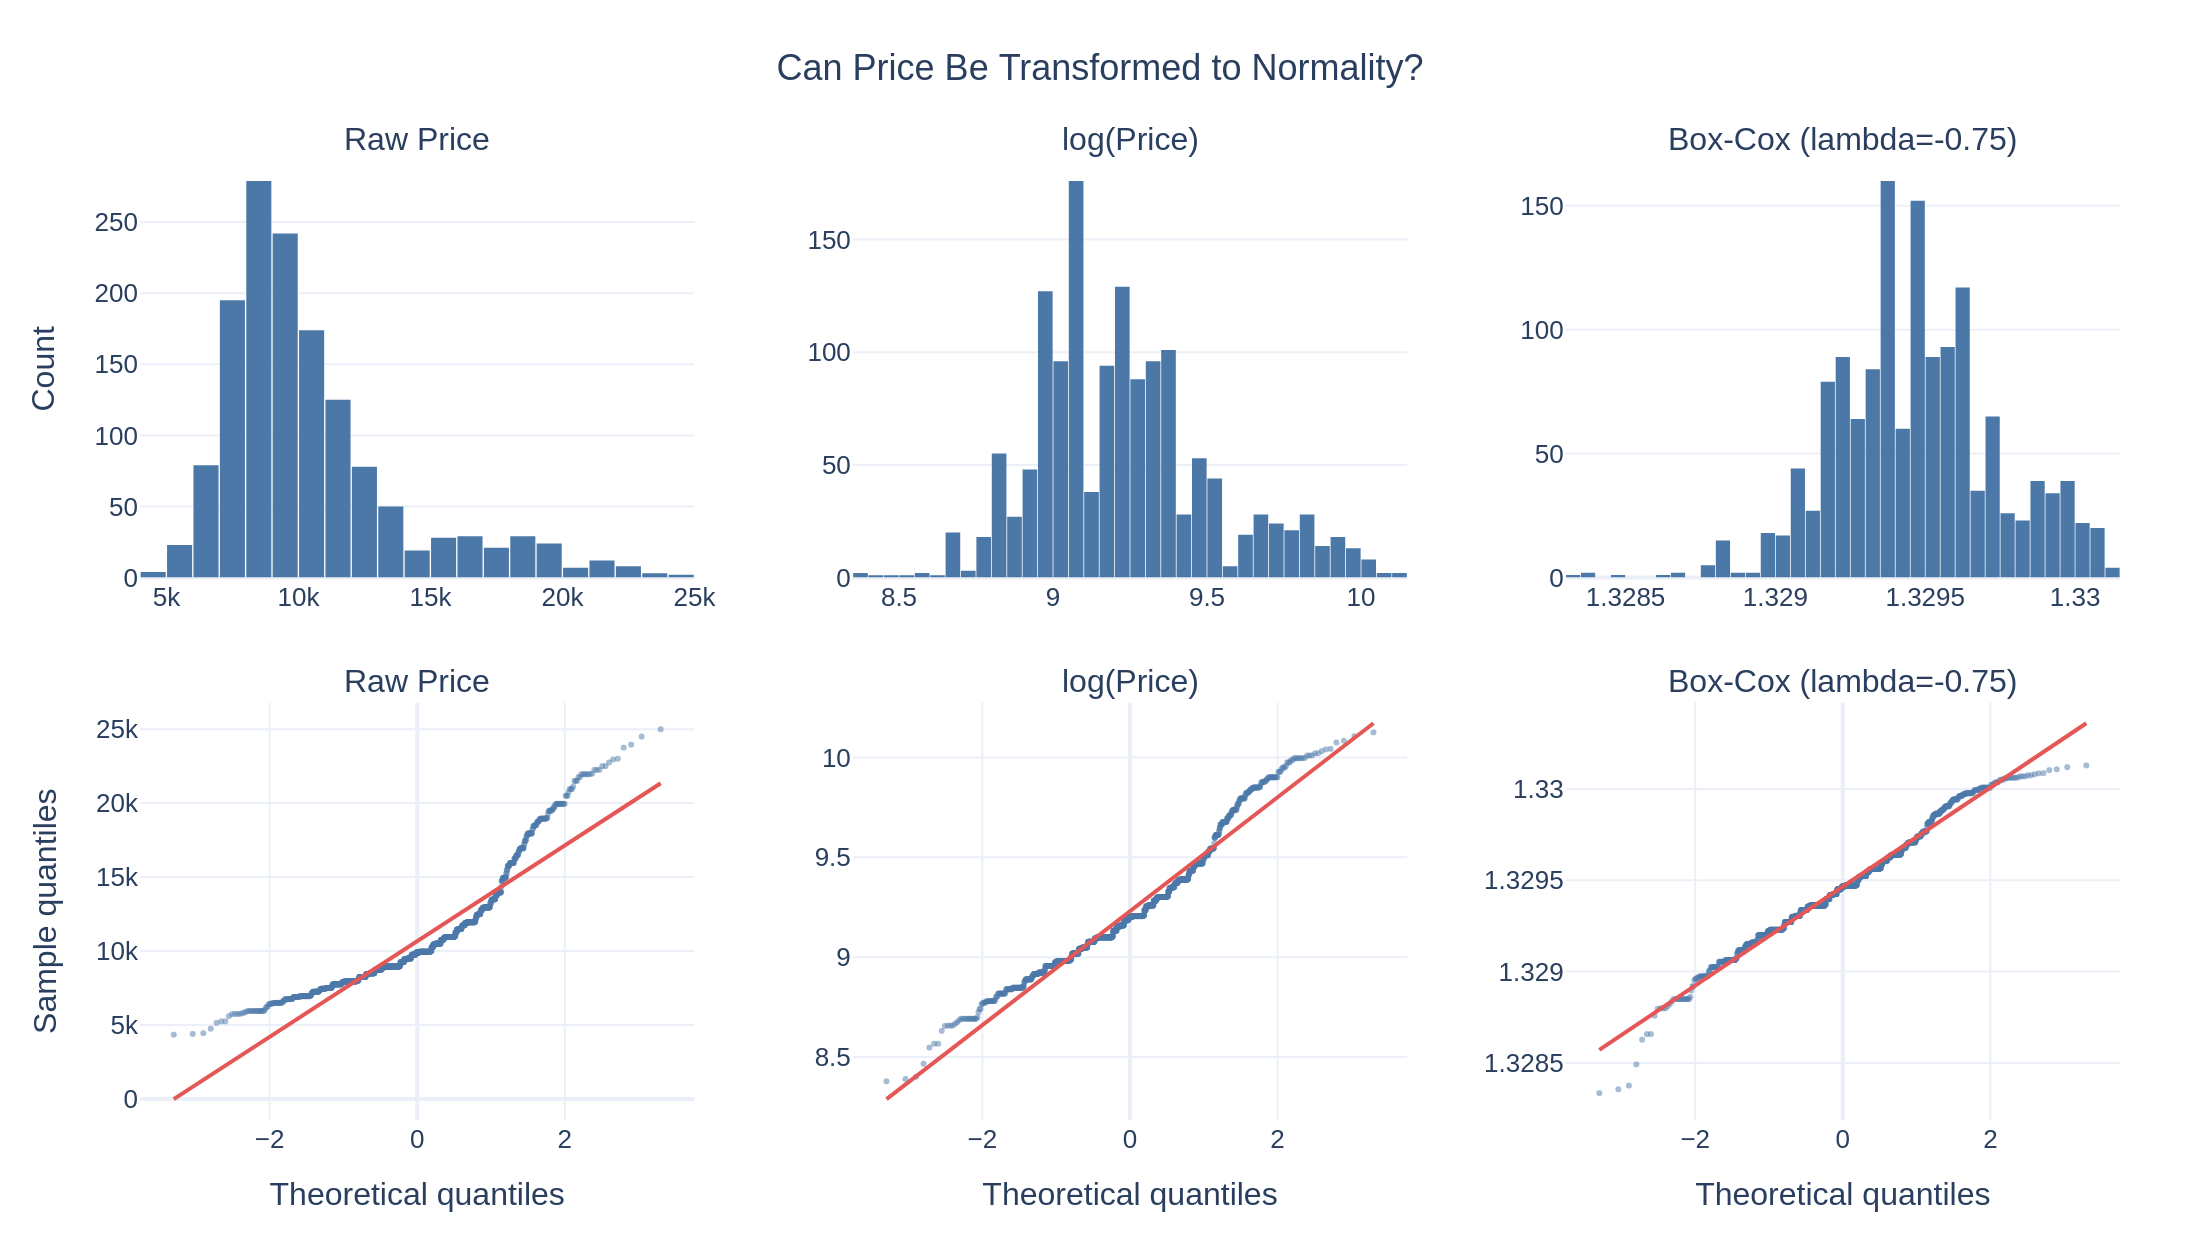

In [11]:
panels = [("Raw Price", price), ("log(Price)", np.log(price)),
          (f"Box-Cox (lambda={lam:.2f})", bc)]

fig = make_subplots(rows=2, cols=3, vertical_spacing=0.13, horizontal_spacing=0.08,
                    subplot_titles=[t for t, _ in panels] * 2)

for j, (title, v) in enumerate(panels, start=1):
    fig.add_trace(go.Histogram(x=v, nbinsx=40, marker_color="#4C78A8",
                               showlegend=False), row=1, col=j)

    osm, osr = stats.probplot(v, dist="norm")[0]
    fig.add_trace(go.Scattergl(x=osm, y=osr, mode="markers",
                               marker=dict(size=3, color="#4C78A8", opacity=0.5),
                               showlegend=False), row=2, col=j)
    slope, intercept = np.polyfit(osm, osr, 1)          # reference line
    fig.add_trace(go.Scatter(x=[osm.min(), osm.max()],
                             y=[slope * osm.min() + intercept,
                                slope * osm.max() + intercept],
                             mode="lines", line=dict(color="#E45756", width=2),
                             showlegend=False), row=2, col=j)
    fig.update_xaxes(title_text="Theoretical quantiles", row=2, col=j)

fig.update_yaxes(title_text="Count", row=1, col=1)
fig.update_yaxes(title_text="Sample quantiles", row=2, col=1)
fig.update_layout(**LAYOUT, height=620, width=1100, bargap=0.05,
                  title=dict(text="Can Price Be Transformed to Normality?",
                             x=0.5, xanchor="center"))
show(fig)

In [12]:
# Assumption check for parametric group tests, done without fitting any model.
# Levene tests whether the nine Age x KM cells share a common variance;
# Shapiro-Wilk tests normality inside each cell.
df_chk = df.assign(
    Age_g=pd.qcut(df["Age_08_04"], 3, labels=["Young", "Mid", "Old"]),
    KM_g=pd.qcut(df["KM"], 3, labels=["Low KM", "Medium KM", "High KM"]),
    log_Price=np.log(df["Price"]),
)

cells = [g["log_Price"].values
         for _, g in df_chk.groupby(["Age_g", "KM_g"], observed=True)]

print(f"Cells: {len(cells)}   sizes: {min(len(c) for c in cells)}-{max(len(c) for c in cells)}")
print(f"Levene  (equal variances) p = {stats.levene(*cells).pvalue:.2e}")
print(f"Fligner (rank-based)      p = {stats.fligner(*cells).pvalue:.2e}")

rejected = sum(stats.shapiro(c).pvalue < 0.05 for c in cells)
print(f"Shapiro-Wilk: {rejected} of {len(cells)} cells reject normality at alpha = 0.05")

Cells: 9   sizes: 54-313
Levene  (equal variances) p = 8.74e-39
Fligner (rank-based)      p = 7.84e-36
Shapiro-Wilk: 8 of 9 cells reject normality at alpha = 0.05


### Findings

Each transformation improves the shape, but none produces a normal distribution.

| Transformation | Skewness | Excess kurtosis | Shapiro-Wilk p |
|---|---|---|---|
| Raw     | +1.46  | +2.04 | 5.4e-33 |
| sqrt    | +1.07  | +1.00 | 1.7e-26 |
| log     | +0.66  | +0.36 | 9.3e-19 |
| Box-Cox (lambda = -0.75) | **-0.01** | +0.35 | **9.7e-10** |

Box-Cox is the strongest possible case: it selects the optimal power and reduces skewness
to essentially zero. Normality is still rejected. The Q-Q plots show why — the departure
is concentrated in the upper tail, where a small number of high-priced cars sit well above
the reference line, and no power transformation removes that.

Box-Cox also carries a cost. A lambda of -0.75 means analysing Price raised to the power
-0.75, a scale with no economic meaning. For an explanatory analysis reported in euros,
that is a poor trade.

**Two conclusions follow.**

1. **For this EDA**, price distributions cannot be assumed normal. Rank-based methods,
   which make no distributional assumption, are the appropriate choice. This is an
   evidence-based decision, not a default.
2. **For a future model**, `log(Price)` remains a reasonable recommendation. It removes
   most of the skew, keeps a clear interpretation as proportional change, and suits the
   economic logic that depreciation is proportional rather than a fixed amount. We return
   to this in Part C.

We do not standardise or rescale the variables. Pearson's correlation is invariant to
linear transformations and Spearman's is invariant to any monotonic one, so scaling would
change none of the results below, while replacing euros and kilometres with standard
deviations would cost interpretability. Scaling is required for distance-based methods,
which are outside the scope of this analysis.

The assumptions required by parametric group comparisons are formally rejected. Levene's
test gives p = 8.7e-39 and the rank-based Fligner test p = 7.8e-36, so the nine Age x KM
cells do not share a common variance; Shapiro-Wilk rejects normality in 8 of the 9 cells
even after the log transformation. Rank-based tests are therefore the appropriate choice,
and this is an evidence-based decision rather than a default.

## Step 2 — The direct relationship with price

### 6. The direct relationship with price

Each variable is plotted against price with a LOWESS smoother, which follows the data
locally and reveals the shape of the relationship. A straight dashed line is drawn on the
same axes: where the two diverge, the relationship is not linear.

LOWESS is used here as an exploratory visualisation of shape. It is not a fitted model
and produces no coefficients.

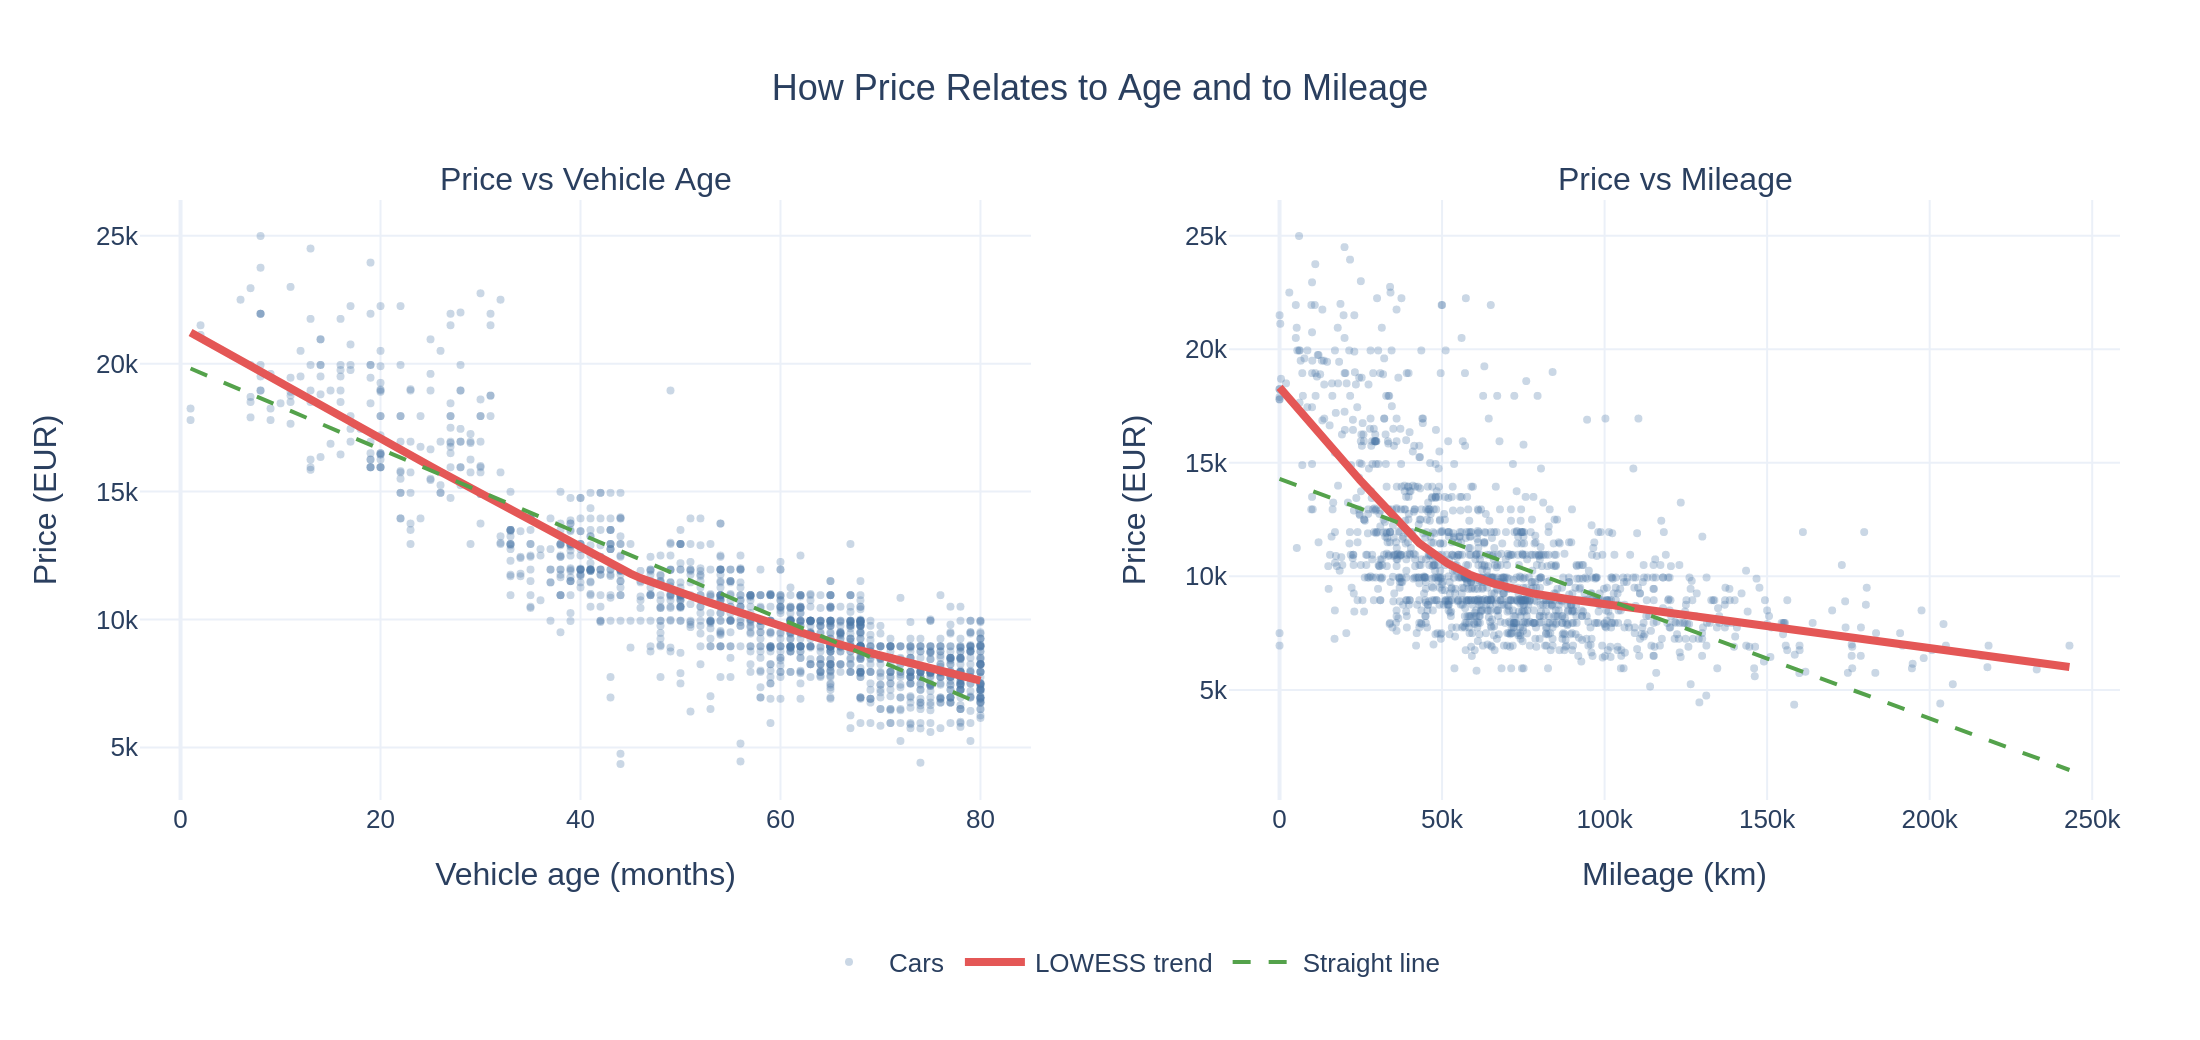

In [13]:
from statsmodels.nonparametric.smoothers_lowess import lowess

PANELS = [("Age_08_04", "Vehicle age (months)"), ("KM", "Mileage (km)")]

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.10,
                    subplot_titles=("Price vs Vehicle Age", "Price vs Mileage"))

for j, (xcol, xlab) in enumerate(PANELS, start=1):
    # Points first, with transparency because 1,431 markers overlap heavily.
    fig.add_trace(go.Scattergl(
        x=df[xcol], y=df["Price"], mode="markers", name="Cars",
        marker=dict(size=4, opacity=0.30, color="#4C78A8"), showlegend=(j == 1),
        hovertemplate=f"{xlab}: %{{x:,.0f}}<br>Price: %{{y:,.0f}} EUR<extra></extra>"
    ), row=1, col=j)

    # LOWESS: a local smoother used to reveal shape, not a fitted model.
    sm = lowess(df["Price"], df[xcol], frac=2/3, return_sorted=True)
    fig.add_trace(go.Scatter(
        x=sm[:, 0], y=sm[:, 1], mode="lines", name="LOWESS trend",
        line=dict(color="#E45756", width=4), showlegend=(j == 1),
        hovertemplate="Trend: %{y:,.0f} EUR<extra></extra>"
    ), row=1, col=j)

    # Straight line for visual comparison: where the two diverge, the relationship curves.
    slope, intercept = np.polyfit(df[xcol], df["Price"], 1)
    xr = np.array([df[xcol].min(), df[xcol].max()])
    fig.add_trace(go.Scatter(
        x=xr, y=intercept + slope * xr, mode="lines", name="Straight line",
        line=dict(color="#54A24B", width=2, dash="dash"),
        showlegend=(j == 1), hoverinfo="skip"
    ), row=1, col=j)

    fig.update_xaxes(title_text=xlab, row=1, col=j)
    fig.update_yaxes(title_text="Price (EUR)", row=1, col=j)

fig.update_layout(**LAYOUT, height=520, width=1100,
                  title=dict(text="How Price Relates to Age and to Mileage",
                             x=0.5, xanchor="center"),
                  legend=dict(orientation="h", x=0.5, xanchor="center",
                              y=-0.22, yanchor="top"))
fig.update_layout(margin=dict(t=100, b=120))
show(fig)

### 7. Is the relationship linear? Pearson against Spearman

Shape is judged with a number rather than by eye. Pearson measures linear association;
Spearman measures monotonic association and is unaffected by any monotonic transformation.
Comparing them therefore diagnoses curvature:

- `|r| > |rho|` — the relationship is close to a straight line.
- `|rho| > |r|` — the relationship is monotonic but curved, so a straight line understates it.

In [14]:
def correlation_row(x, y, label):
    pr = stats.pearsonr(df[x], df[y])
    sp = stats.spearmanr(df[x], df[y])
    return {"Relationship": label,
            "Pearson r": pr.statistic, "Pearson p": pr.pvalue,
            "Spearman rho": sp.statistic, "Spearman p": sp.pvalue,
            "|rho| - |r|": abs(sp.statistic) - abs(pr.statistic)}

corr = pd.DataFrame([
    correlation_row("Age_08_04", "Price", "Age - Price"),
    correlation_row("KM", "Price", "KM - Price"),
    correlation_row("Age_08_04", "KM", "Age - KM"),
])

out = corr.copy()
for c in ["Pearson r", "Spearman rho", "|rho| - |r|"]:
    out[c] = out[c].map(lambda v: f"{v:+.3f}")
for c in ["Pearson p", "Spearman p"]:
    out[c] = out[c].map(lambda v: "<0.001" if v < 0.001 else f"{v:.3f}")

display(out.set_index("Relationship"))

,Pearson r,Pearson p,Spearman rho,Spearman p,|rho| - |r|
Relationship,,,,,
Age - Price,-0.881,<0.001,-0.841,<0.001,-0.040
KM - Price,-0.570,<0.001,-0.612,<0.001,+0.042
Age - KM,+0.499,<0.001,+0.527,<0.001,+0.028


In [15]:
# A straight line and the LOWESS curve are compared by how much of the variance in
# Price each one tracks. The gap quantifies the curvature seen in the plot above.
def variance_tracked(x, y):
    ss_tot   = np.sum((y - y.mean()) ** 2)
    straight = np.polyval(np.polyfit(x, y, 1), x)
    curve    = lowess(y, x, frac=2/3, return_sorted=False)
    return (1 - np.sum((y - straight) ** 2) / ss_tot,
            1 - np.sum((y - curve) ** 2) / ss_tot)

rows = []
for xcol, xlab in PANELS:
    s, c = variance_tracked(df[xcol].values, df["Price"].values)
    rows.append({"Predictor": xlab, "Straight line": s, "LOWESS curve": c, "Gain": c - s})
display(pd.DataFrame(rows).set_index("Predictor").style.format("{:.4f}"))

,Straight line,LOWESS curve,Gain
Predictor,,,
Vehicle age (months),0.7755,0.8110,0.0356
Mileage (km),0.3244,0.4438,0.1194


### Findings

| Relationship | Pearson r | Spearman rho | \|rho\| - \|r\| | Reading |
|---|---|---|---|---|
| Age – Price | **-0.881** | -0.841 | **-0.040** | close to linear |
| KM – Price  | -0.570 | **-0.612** | **+0.042** | monotonic but curved |
| Age – KM    | +0.499 | +0.527 | +0.029 | the two predictors move together |

All correlations are significant at p < 0.001, but at n = 1,431 significance is almost
guaranteed. The informative content is in the strength and in the sign of the gap.

**Age is the dominant relationship and it is close to linear.** Pearson exceeds Spearman
(0.881 vs 0.841), consistent with the near-straight LOWESS curve. Price falls at a fairly
steady rate per month of age across most of the observed range.

**Mileage matters less and its relationship is curved.** Spearman exceeds Pearson
(0.612 vs 0.570), the opposite sign of gap, and the LOWESS curve departs visibly from the
dashed straight line: price drops steeply over the first kilometres and then flattens.
The variance comparison puts a size on this — a straight line tracks 32.4% of the variance
in price, the LOWESS curve tracks 44.4%, so **a straight line misses about 12 percentage
points of the mileage relationship**. For age the same gap is only 3.6 points, confirming
that curvature is a mileage problem, not an age problem.

**Age and mileage are themselves correlated (r = +0.499).** Older cars have travelled
further, so their raw associations with price overlap and cannot both be taken at face
value. This is the question the next section addresses.

## Step 3 — Separating age from mileage

### 8. Separating age from mileage

Age and mileage are correlated (r = +0.499): older cars have travelled further. Their raw
associations with price therefore overlap, and neither can be read at face value.

The causal structure decides how to handle this. Age precedes mileage — a car accumulates
kilometres over time — and it affects price through channels of its own, such as model year,
wear and remaining warranty. This gives:

    Age -> Price
    Age -> KM -> Price

The role of each variable depends on which question is being asked:

- **Asking about mileage**, age is a **confounder**: it precedes mileage and influences both
  mileage and price. Controlling for it is required.
- **Asking about age**, mileage is a **mediator**: it lies on a pathway from age to price.
  Controlling for it removes that pathway and leaves only the direct effect, not the total one.

Partial correlations are computed on ranks, consistent with the non-normal distributions
established above.

In [16]:
def partial_corr(r_xy, r_xz, r_yz):
    """Correlation between x and y after removing what z predicts in both."""
    return (r_xy - r_xz * r_yz) / np.sqrt((1 - r_xz ** 2) * (1 - r_yz ** 2))

n, dfree = len(df), len(df) - 3          # one control variable costs one df

def partial_p(r):
    t = r * np.sqrt(dfree / (1 - r ** 2))
    return 2 * stats.t.sf(abs(t), dfree)

# Rank-based, consistent with the non-normal distributions established earlier.
rho_age_price = stats.spearmanr(df["Age_08_04"], df["Price"]).statistic
rho_km_price  = stats.spearmanr(df["KM"],        df["Price"]).statistic
rho_age_km    = stats.spearmanr(df["Age_08_04"], df["KM"]).statistic

p_age = partial_corr(rho_age_price, rho_age_km, rho_km_price)
p_km  = partial_corr(rho_km_price,  rho_age_km, rho_age_price)

partial = pd.DataFrame([
    {"Relationship": "Age - Price (control: KM)",
     "Ordinary rho": rho_age_price, "Partial rho": p_age,
     "Reduction": abs(rho_age_price) - abs(p_age),
     "Reduction %": 100 * (abs(rho_age_price) - abs(p_age)) / abs(rho_age_price),
     "Partial p": partial_p(p_age)},
    {"Relationship": "KM - Price (control: Age)",
     "Ordinary rho": rho_km_price, "Partial rho": p_km,
     "Reduction": abs(rho_km_price) - abs(p_km),
     "Reduction %": 100 * (abs(rho_km_price) - abs(p_km)) / abs(rho_km_price),
     "Partial p": partial_p(p_km)},
]).set_index("Relationship")

out = partial.copy()
for c in ["Ordinary rho", "Partial rho", "Reduction"]:
    out[c] = out[c].map(lambda v: f"{v:+.3f}")
out["Reduction %"] = out["Reduction %"].map(lambda v: f"{v:.1f}%")
out["Partial p"]   = out["Partial p"].map(lambda v: "<0.001" if v < 0.001 else f"{v:.3f}")
display(out)

,Ordinary rho,Partial rho,Reduction,Reduction %,Partial p
Relationship,,,,,
Age - Price (control: KM),-0.841,-0.771,+0.070,8.3%,<0.001
KM - Price (control: Age),-0.612,-0.366,+0.246,40.2%,<0.001


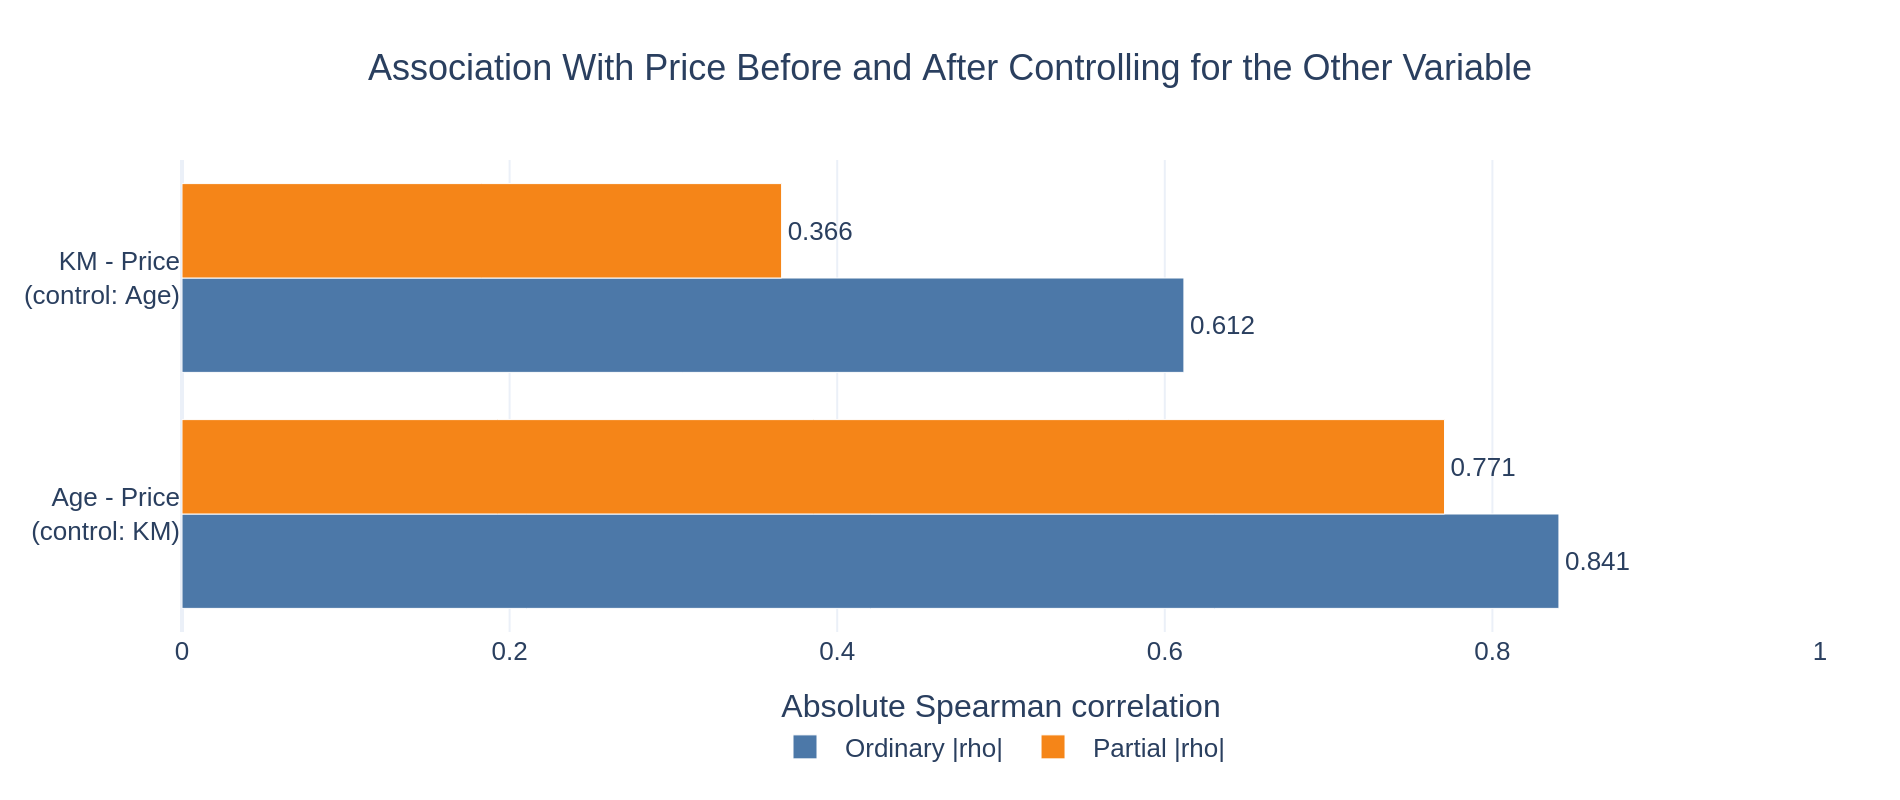

In [17]:
labels = ["Age - Price<br>(control: KM)", "KM - Price<br>(control: Age)"]
ordinary = [abs(rho_age_price), abs(rho_km_price)]
partial_v = [abs(p_age), abs(p_km)]

fig = go.Figure()
fig.add_trace(go.Bar(y=labels, x=ordinary, name="Ordinary |rho|", orientation="h",
                     marker_color="#4C78A8",
                     text=[f"{v:.3f}" for v in ordinary], textposition="outside"))
fig.add_trace(go.Bar(y=labels, x=partial_v, name="Partial |rho|", orientation="h",
                     marker_color="#F58518",
                     text=[f"{v:.3f}" for v in partial_v], textposition="outside"))

fig.update_layout(**LAYOUT, height=400, width=950, barmode="group",
                  title=dict(text="Association With Price Before and After Controlling "
                                  "for the Other Variable", x=0.5, xanchor="center"),
                  xaxis_title="Absolute Spearman correlation", xaxis_range=[0, 1],
                  legend=dict(orientation="h", x=0.5, xanchor="center",
                              y=-0.18, yanchor="top"))
show(fig)

### Findings

| Relationship | Ordinary rho | Partial rho | Reduction |
|---|---|---|---|
| Age – Price (control: KM) | -0.841 | **-0.771** | **8.3%** |
| KM – Price (control: Age) | -0.612 | **-0.366** | **40.2%** |

Both partial correlations remain significant at p < 0.001. The informative result is how
differently the two are affected.

**Age survives almost intact.** Controlling for mileage costs it only 8.3% of its
association with price. Most of what age does to price does not travel through the
odometer — it works through model year, wear, remaining warranty and buyer perception.
Note that this is the *direct* effect only; because mileage is a mediator, the ordinary
correlation of -0.841 is the better estimate of what age is worth in total.

**Mileage loses most of its apparent association.** Controlling for age cuts it by 40.2%,
from -0.612 to -0.366. In shared-variance terms, mileage alone tracks 37.4% of the
variation in price ranks, but only 13.4% once age is held constant. **Roughly two thirds
of the apparent mileage–price relationship is age wearing a mileage disguise.**

**Both still carry independent information.** Neither partial correlation collapses to
zero, so age and mileage are not interchangeable and both belong in any later model.

This also settles a question the raw correlations could not: **age is the primary driver
of depreciation, and mileage is a genuine but secondary one.** What remains open is
whether the mileage effect is the same for every car — which is the second half of the
research question and the subject of the next section.

## Step 4 — Does the mileage effect depend on age?

### 9. Does the mileage effect depend on age?

The second half of the research question asks whether the relationship changes across
levels of the other variable. In the terminology of the course, this asks whether one
variable **moderates** the other: does it change the *magnitude* of the relationship?

Both variables are continuous, so we stratify them into tertiles. Quantile binning is used
rather than equal-width bins: because age and mileage are correlated, equal-width bins
would leave some combinations almost empty.

Three pieces of evidence follow — a stratified plot, a two-way median table, and a
rank-based test of the mileage effect inside each age stratum.

In [18]:
# Quantile binning (equal frequency). Equal-width bins would create near-empty cells
# because age and mileage are correlated (r = +0.499).
df["Age_group"] = pd.qcut(df["Age_08_04"], 3, labels=["Young", "Mid", "Old"])
df["KM_group"]  = pd.qcut(df["KM"],        3, labels=["Low KM", "Medium KM", "High KM"])

edges = {"Age tertile edges (months)": pd.qcut(df["Age_08_04"], 3).cat.categories,
         "KM tertile edges (km)":      pd.qcut(df["KM"], 3).cat.categories}
for k, v in edges.items():
    print(f"{k}: {[str(i) for i in v]}")

print("\nCell sizes:")
display(pd.crosstab(df["Age_group"], df["KM_group"]))

Age tertile edges (months): ['(0.999, 51.0]', '(51.0, 67.0]', '(67.0, 80.0]']
KM tertile edges (km): ['(0.999, 50000.0]', '(50000.0, 77549.333]', '(77549.333, 243000.0]']

Cell sizes:


KM_group,Low KM,Medium KM,High KM
Age_group,,,
Young,313,103,65
Mid,111,208,170
Old,54,165,242


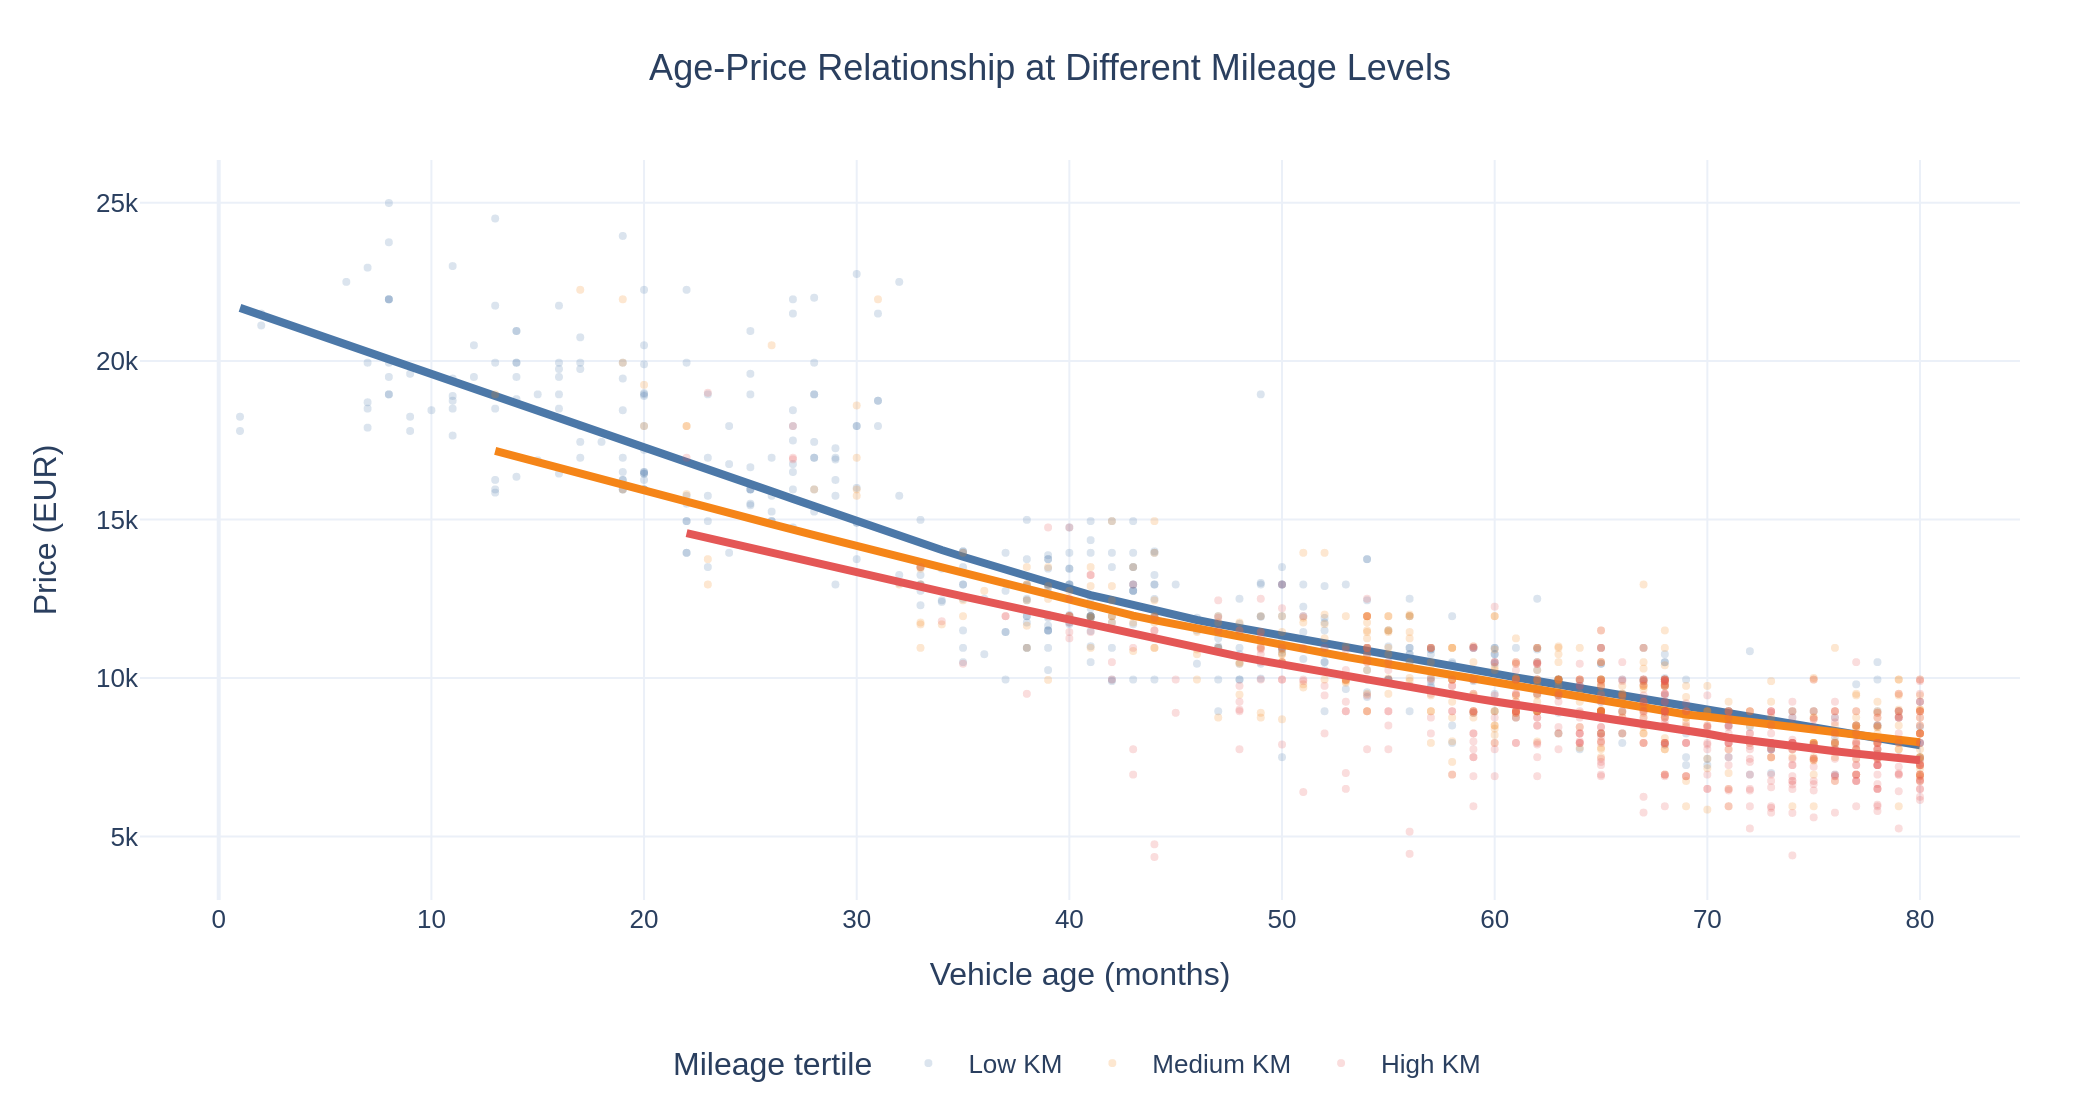

In [19]:
from statsmodels.nonparametric.smoothers_lowess import lowess

COLORS = {"Low KM": "#4C78A8", "Medium KM": "#F58518", "High KM": "#E45756"}

fig = go.Figure()
for lvl in df["KM_group"].cat.categories:
    g = df[df["KM_group"] == lvl]
    fig.add_trace(go.Scattergl(x=g["Age_08_04"], y=g["Price"], mode="markers",
                               name=lvl, legendgroup=lvl, hoverinfo="skip",
                               marker=dict(size=4, opacity=0.20, color=COLORS[lvl])))
    sm = lowess(g["Price"], g["Age_08_04"], frac=2/3, return_sorted=True)
    fig.add_trace(go.Scatter(x=sm[:, 0], y=sm[:, 1], mode="lines",
                             name=lvl + " trend", legendgroup=lvl, showlegend=False,
                             line=dict(color=COLORS[lvl], width=4)))

fig.update_layout(**LAYOUT, height=560, width=1050,
                  title=dict(text="Age-Price Relationship at Different Mileage Levels",
                             x=0.5, xanchor="center"),
                  xaxis_title="Vehicle age (months)", yaxis_title="Price (EUR)",
                  legend=dict(title="Mileage tertile", orientation="h",
                              x=0.5, xanchor="center", y=-0.18, yanchor="top"))
show(fig)

### 10. Quantifying the change in effect

Kruskal-Wallis compares price distributions across mileage groups **within** each age
stratum. It is rank-based and makes no distributional assumption, which matters here
because normality was rejected earlier even after a Box-Cox transformation.

At these sample sizes p-values are uninformative — almost any real difference reaches
significance. The effect size epsilon-squared is what allows the three strata to be
compared, since it measures how much of the variation in price ranks the mileage grouping
accounts for.

In [20]:
def effect_sizes(H, n, k=3):
    """Two standard effect sizes for Kruskal-Wallis (Tomczak & Tomczak, 2014).
    epsilon-squared = H / (n - 1)  is the conventional measure.
    eta-squared[H]  = (H - k + 1) / (n - k)  is a related measure, reported for completeness.
    scipy.stats.kruskal already applies the standard correction for ties."""
    return H / (n - 1), (H - k + 1) / (n - k)

rows = []
for age in df["Age_group"].cat.categories:
    s = df[df["Age_group"] == age]
    groups  = [s.loc[s["KM_group"] == k, "Price"].values for k in df["KM_group"].cat.categories]
    H, p    = stats.kruskal(*groups)
    medians = [np.median(g) for g in groups]
    eps, eta = effect_sizes(H, len(s))
    rows.append({"Age group": age, "n": len(s), "H": H, "p": p,
                 "Epsilon-squared": eps, "Eta-squared (H)": eta,
                 "Median spread (EUR)": max(medians) - min(medians)})

strat = pd.DataFrame(rows).set_index("Age group")
display(strat.style.format({"H": "{:.2f}", "p": "{:.2e}",
                            "Epsilon-squared": "{:.4f}", "Eta-squared (H)": "{:.4f}",
                            "Median spread (EUR)": "{:,.0f}"}))

,n,H,p,Epsilon-squared,Eta-squared (H),Median spread (EUR)
Age group,,,,,,
Young,481,88.54,5.95e-20,0.1844,0.1810,"2,545"
Mid,489,55.44,9.16e-13,0.1136,0.1100,"1,050"
Old,461,32.15,1.04e-07,0.0699,0.0658,575


In [21]:
# Kruskal-Wallis says at least one group differs; Dunn says which pairs.
# Bonferroni keeps the family-wise error rate at 5% across the three comparisons.
try:
    import scikit_posthocs as sp
except ImportError:
    !pip install scikit-posthocs -q
    import scikit_posthocs as sp

PAIRS = [("Low KM", "Medium KM"), ("Low KM", "High KM"), ("Medium KM", "High KM")]

rows = []
for age in df["Age_group"].cat.categories:
    s = df[df["Age_group"] == age]
    m = sp.posthoc_dunn(s, val_col="Price", group_col="KM_group", p_adjust="bonferroni")
    rows.append({"Age group": age, **{f"{a} vs {b}": m.loc[a, b] for a, b in PAIRS}})

display(pd.DataFrame(rows).set_index("Age group").style.format("{:.3g}"))

,Low KM vs Medium KM,Low KM vs High KM,Medium KM vs High KM
Age group,,,
Young,6.2e-09,2.33e-16,0.0121
Mid,0.0127,2.69e-12,6.57e-07
Old,0.813,4.88e-05,7.17e-06


KM_group,Low KM,Medium KM,High KM
Age_group,,,
Young,"13,995","11,950","11,450"
Mid,"10,000","9,800","8,950"
Old,"8,500","8,450","7,925"


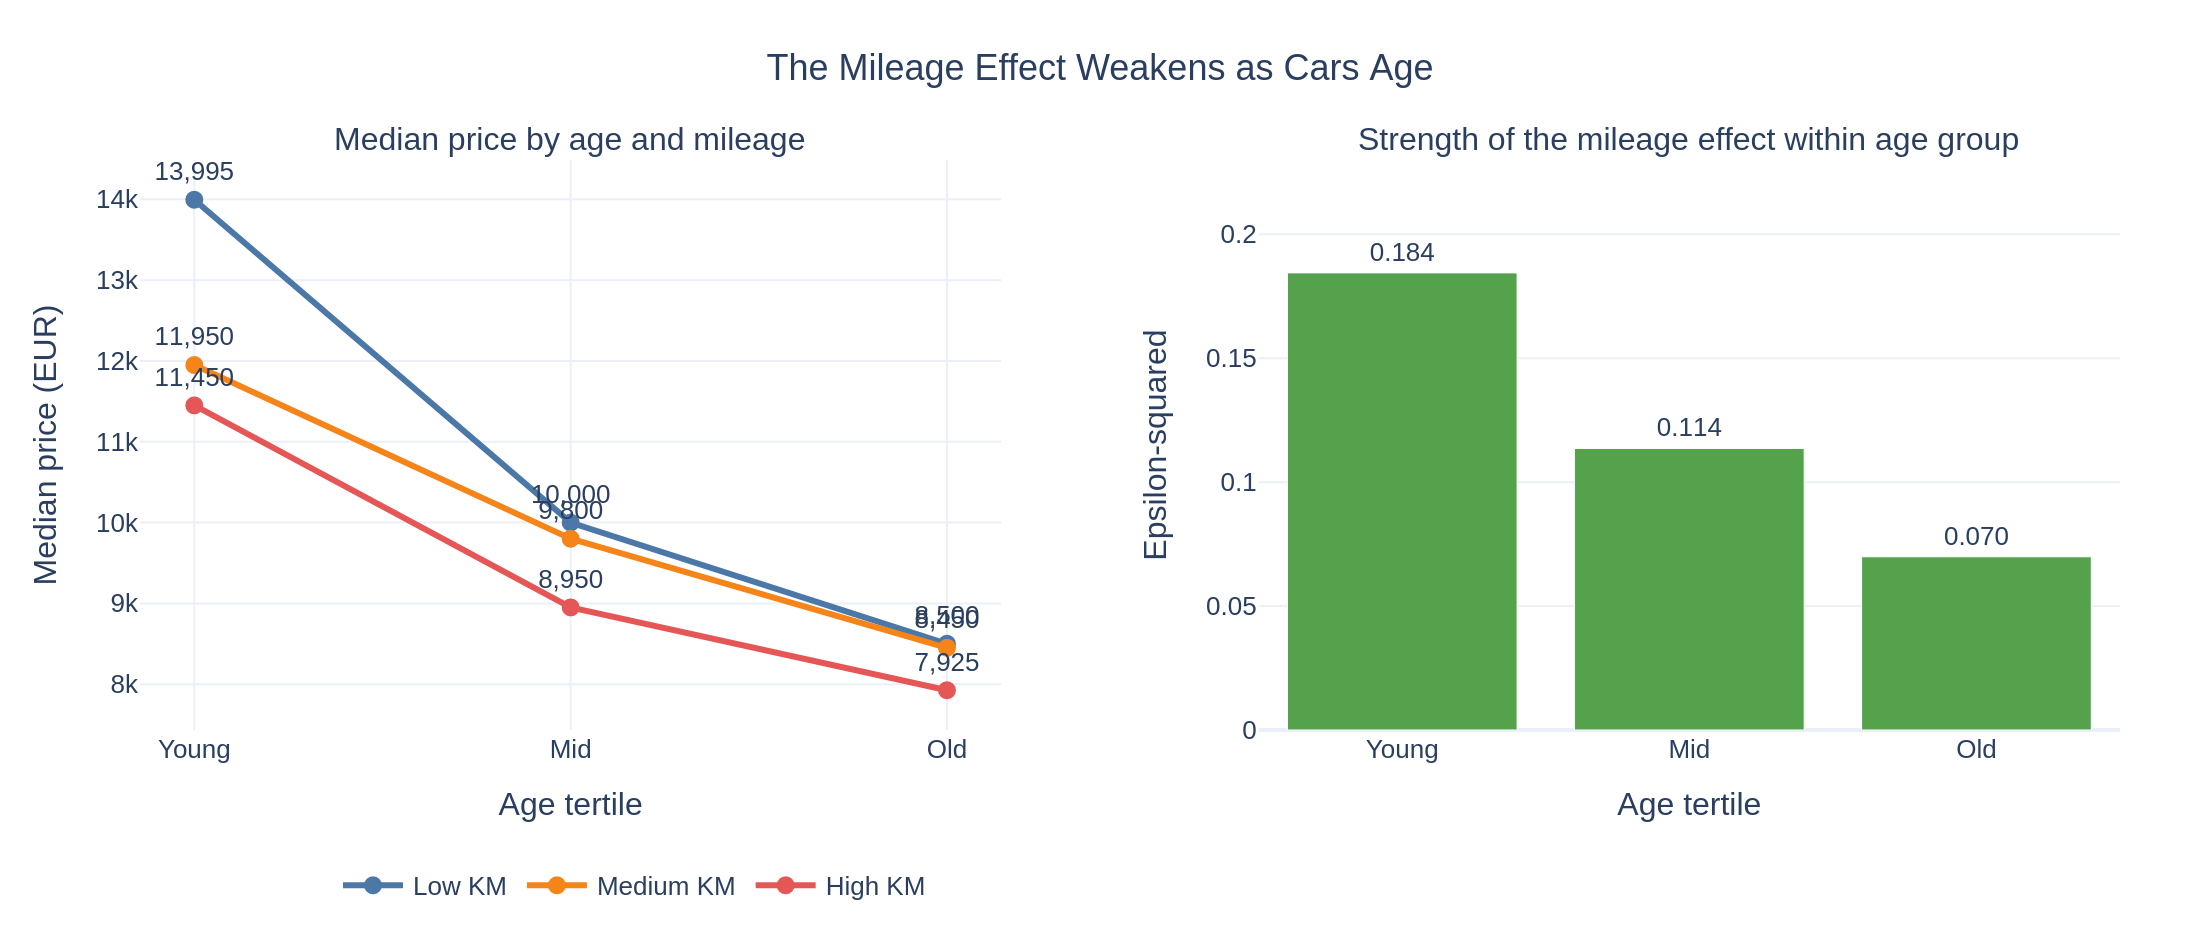

In [22]:
median_grid = df.pivot_table(index="Age_group", columns="KM_group",
                             values="Price", aggfunc="median", observed=True)
display(median_grid.style.format("{:,.0f}"))

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.13,
                    subplot_titles=("Median price by age and mileage",
                                    "Strength of the mileage effect within age group"))

for lvl in df["KM_group"].cat.categories:
    fig.add_trace(go.Scatter(x=list(median_grid.index), y=median_grid[lvl].values,
                             mode="lines+markers+text", name=lvl,
                             line=dict(color=COLORS[lvl], width=3), marker=dict(size=9),
                             text=[f"{v:,.0f}" for v in median_grid[lvl].values],
                             textposition="top center"), row=1, col=1)

fig.add_trace(go.Bar(x=list(strat.index), y=strat["Epsilon-squared"],
                     marker_color="#54A24B", showlegend=False,
                     text=[f"{v:.3f}" for v in strat["Epsilon-squared"]],
                     textposition="outside"), row=1, col=2)

fig.update_yaxes(title_text="Median price (EUR)", row=1, col=1)
fig.update_yaxes(title_text="Epsilon-squared", row=1, col=2, range=[0, 0.23])
fig.update_xaxes(title_text="Age tertile", row=1, col=1)
fig.update_xaxes(title_text="Age tertile", row=1, col=2)
fig.update_layout(**LAYOUT, height=470, width=1100,
                  title=dict(text="The Mileage Effect Weakens as Cars Age",
                             x=0.5, xanchor="center"),
                  legend=dict(orientation="h", x=0.25, xanchor="center",
                              y=-0.22, yanchor="top"))
show(fig)

### Findings

| Age group | n | H | p | Epsilon-squared | Median spread |
|---|---|---|---|---|---|
| Young (1–51 months)  | 481 | 88.54 | 6.0e-20 | **0.184** | **EUR 2,545** |
| Mid (52–67 months)   | 489 | 55.44 | 9.2e-13 | **0.114** | EUR 1,050 |
| Old (68–80 months)   | 461 | 32.15 | 1.0e-07 | **0.070** | **EUR 575** |

**The mileage effect weakens steadily as cars age.** Epsilon-squared falls from 0.184 to
0.070 — a **62% reduction in effect size** — and the gap between the cheapest and dearest
mileage group narrows from EUR 2,545 to EUR 575, a **4.4-fold contraction**. Mileage
separates prices sharply among young cars and only faintly among old ones.

**The effect weakens; it does not disappear.** Even in the oldest tertile the test remains
significant (p = 1.0e-07). Any claim that mileage stops mattering entirely is not supported
by these data. What the evidence shows is attenuation — a change in magnitude, which is
precisely what moderation means.

**Where the flattening happens is visible in the post-hoc comparisons.**

| Age group | Low vs Medium | Low vs High | Medium vs High |
|---|---|---|---|
| Young | 6.2e-09 | 2.3e-16 | 0.012 |
| Mid   | 0.013   | 2.7e-12 | 6.6e-07 |
| Old   | **0.813** | 4.9e-05 | 7.2e-06 |

Among young cars all three mileage tiers command distinguishable prices. Among old cars,
low- and medium-mileage vehicles are **no longer distinguishable** (p = 0.81): only cars in
the top mileage tier still trade at a discount. The market stops paying for the difference
between a modest and a moderate odometer reading once the car is old enough — a partial
price floor rather than an absolute one.

**Reading the question in the other direction** confirms the same structure. In the median
table the three mileage lines start EUR 2,545 apart among young cars and converge to within
EUR 575 among old ones. The age–price gradient is also steepest for low-mileage cars
(13,995 to 8,500, a fall of EUR 5,495) and shallowest for high-mileage cars
(11,450 to 7,925, a fall of EUR 3,525). Age and mileage do not act independently: each one
weakens the influence of the other.

**Caveat.** The cells are unbalanced — 313 cars are young with low mileage while only 65
are young with high mileage, and the pattern reverses among old cars. This is the age–mileage
correlation reappearing, and it means the sparser cells carry wider uncertainty. It does not
change the direction of the finding, which is consistent across all three strata and across
both readings of the table.

## Step 5 — Sensitivity of the conclusion

### 11. Sensitivity of the conclusion

Three decisions were made during cleaning: excluding the Verso models, retaining two
records with implausible mileage, and splitting the continuous variables into tertiles.
Each is repeated here to check whether the conclusion depends on it.

In [23]:
def mileage_effect_by_age(data, q=3):
    """Kruskal-Wallis of price across mileage groups, within each age stratum."""
    d = data.copy()
    d["A"] = pd.qcut(d["Age_08_04"], q)
    d["K"] = pd.qcut(d["KM"], q)
    rows = []
    for a in d["A"].cat.categories:
        s = d[d["A"] == a]
        groups = [s.loc[s["K"] == k, "Price"].values for k in d["K"].cat.categories]
        groups = [g for g in groups if len(g) > 0]
        H, p = stats.kruskal(*groups)
        med = [np.median(g) for g in groups]
        rows.append({"Age stratum": str(a), "n": len(s), "p": p,
                     "Epsilon-squared": H / (len(s) - 1),
                     "Median spread (EUR)": max(med) - min(med)})
    return pd.DataFrame(rows).set_index("Age stratum")

scenarios = {
    "Main analysis (n = 1,431)":      df,
    "Verso included (n = 1,436)":     df_all[VARS],
    "Suspect KM removed (n = 1,429)": df[~((df["KM"] <= 1) & (df["Age_08_04"] > 24))],
}

rows = []
for name, data in scenarios.items():
    r = mileage_effect_by_age(data)
    e_young, e_old = r["Epsilon-squared"].iloc[0], r["Epsilon-squared"].iloc[-1]
    rows.append({"Scenario": name,
                 "Eps2 young": e_young, "Eps2 old": e_old,
                 "Decline %": 100 * (1 - e_old / e_young),
                 "Spread young (EUR)": r["Median spread (EUR)"].iloc[0],
                 "Spread old (EUR)":   r["Median spread (EUR)"].iloc[-1]})

display(pd.DataFrame(rows).set_index("Scenario").style.format(
    {"Eps2 young": "{:.4f}", "Eps2 old": "{:.4f}", "Decline %": "{:.1f}%",
     "Spread young (EUR)": "{:,.0f}", "Spread old (EUR)": "{:,.0f}"}))

,Eps2 young,Eps2 old,Decline %,Spread young (EUR),Spread old (EUR)
Scenario,,,,,
"Main analysis (n = 1,431)",0.1844,0.0699,62.1%,"2,545",575
"Verso included (n = 1,436)",0.1910,0.0699,63.4%,"3,375",575
"Suspect KM removed (n = 1,429)",0.1927,0.0725,62.4%,"2,900",575


In [24]:
# The tertile split is a choice. We repeat the analysis with 4 and 5 bins to see
# whether the conclusion depends on it.
for q, name in [(3, "Tertiles"), (4, "Quartiles"), (5, "Quintiles")]:
    r = mileage_effect_by_age(df, q)
    eps    = " -> ".join(f"{v:.3f}"  for v in r["Epsilon-squared"])
    spread = " -> ".join(f"{v:,.0f}" for v in r["Median spread (EUR)"])
    print(f"{name:10s} epsilon-squared: {eps}")
    print(f"{'':10s} median spread  : {spread}\n")

# Price dispersion itself shrinks with age, which is why the two measures can diverge.
disp = df.assign(A=pd.qcut(df["Age_08_04"], 3)).groupby("A", observed=True)["Price"].agg(
    n="size", Median="median", SD="std",
    IQR=lambda s: s.quantile(0.75) - s.quantile(0.25))
display(disp.style.format({"Median": "{:,.0f}", "SD": "{:,.0f}", "IQR": "{:,.0f}"}))

Tertiles   epsilon-squared: 0.184 -> 0.114 -> 0.070
           median spread  : 2,545 -> 1,050 -> 575

Quartiles  epsilon-squared: 0.153 -> 0.148 -> 0.065 -> 0.107
           median spread  : 4,200 -> 1,675 -> 1,000 -> 950

Quintiles  epsilon-squared: 0.196 -> 0.189 -> 0.147 -> 0.086 -> 0.127
           median spread  : 5,500 -> 1,800 -> 1,525 -> 1,148 -> 1,300



,n,Median,SD,IQR
A,,,,
"(0.999, 51.0]",481,"12,950","3,642","5,100"
"(51.0, 67.0]",489,"9,750","1,291","1,550"
"(67.0, 80.0]",461,"7,950","1,105","1,550"


### Findings

**The conclusion does not depend on the cleaning decisions.**

| Scenario | Eps2 young | Eps2 old | Decline |
|---|---|---|---|
| Main analysis (n = 1,431) | 0.1844 | 0.0699 | **62.1%** |
| Verso included (n = 1,436) | 0.1910 | 0.0699 | **63.4%** |
| Suspect KM removed (n = 1,429) | 0.1927 | 0.0725 | **62.4%** |

The decline in the mileage effect is between 62% and 63% under all three specifications.
Including the five Verso models widens the young-car spread from EUR 2,545 to EUR 3,375 —
they are young, low-mileage and expensive, so they inflate exactly the cell they sit in —
but they do not change the pattern. Excluding them keeps the study population coherent
without altering the result. Removing the two records with implausible mileage moves the
young-car spread to EUR 2,900 and leaves the decline at 62.4%.

**The number of bins matters more, and it matters in an instructive way.**

| Binning | Epsilon-squared across age strata | Median spread (EUR) |
|---|---|---|
| Tertiles  | 0.184 → 0.114 → 0.070 | 2,545 → 1,050 → 575 |
| Quartiles | 0.153 → 0.148 → 0.065 → **0.107** | 4,200 → 1,675 → 1,000 → 950 |
| Quintiles | 0.196 → 0.189 → 0.147 → 0.086 → **0.127** | 5,500 → 1,800 → 1,525 → 1,148 → 1,300 |

The **economic magnitude falls monotonically under every scheme**: the price gap between
mileage groups shrinks steadily with age whether we use three, four or five bins. The
**rank-based effect size does not** — it declines and then rises again in the oldest stratum
once the bins are finer.

The dispersion table explains why. Price variability collapses with age: the standard
deviation falls from EUR 3,642 among young cars to EUR 1,105 among old ones. Epsilon-squared
measures separation relative to the variation that remains, so in the oldest group a modest
gap of EUR 950 still separates the ranks clearly, even though it is small in money terms.
The two measures answer different questions — how much money, and how clean the separation —
and they diverge exactly where price dispersion is smallest.

**A note on reproducibility.** Four cars sit at exactly 50,000 km, which is the first KM
tertile boundary. How ties at that boundary are allocated varies slightly between pandas
versions and shifts the young-stratum effect size by less than 0.001. No reported conclusion
depends on it.

**What survives.** The claim supported by all specifications is that the **monetary penalty
for mileage shrinks substantially as cars age**. The stronger claim that mileage becomes
statistically negligible in old cars is **not** supported: the effect stays significant in
every stratum under every binning, and under finer bins its rank-based strength partially
recovers. We report the weaker, defensible claim.
\

# Part B — Conclusions and Practical Insights

**1. Age is the primary driver of depreciation.** It shows the strongest association with
price (Spearman rho = -0.841), and controlling for mileage costs it only 8.3% of that
association. Most of what age does to price does not travel through the odometer.

**2. Mileage matters, but less than the raw figures suggest.** Its ordinary correlation of
-0.612 falls to -0.366 once age is held constant — a 40.2% reduction. In shared-variance
terms it drops from 37.4% to 13.4%. **Roughly two thirds of the apparent mileage-price
relationship is age in disguise.**

**3. The two relationships have different shapes.** For age, Pearson exceeds Spearman
(0.881 vs 0.841) and a straight line tracks the relationship well. For mileage the ordering
reverses (0.612 vs 0.570) and a straight line misses about 12 percentage points of variance
that a local smoother captures: price falls steeply over the first kilometres and then
flattens.

**4. The mileage effect depends on age.** Within age strata, the effect size falls by 62%
from young to old cars and the price gap between mileage groups contracts from EUR 2,545 to
EUR 575. Among old cars, low- and medium-mileage vehicles are no longer distinguishable
(Dunn p = 0.81); only the highest mileage tier still trades at a discount.

**5. The effect attenuates rather than vanishes.** Mileage remains significant in every age
stratum. The defensible statement is that the monetary penalty for mileage shrinks
substantially with age — not that it disappears.

### Practical interpretation

For a buyer, an additional 10,000 km costs far more on a young Corolla than on an old one,
so mileage deserves close attention when buying nearly new and much less when buying at six
years. For a seller, the reverse holds: mileage accumulated early is expensive in resale
terms, while mileage accumulated on an already-old car costs comparatively little.

These are associations observed in one dealership dataset from 2004. They describe how this
market priced cars; they are not causal effects, and the analysis does not establish that
adding kilometres *causes* a specific loss in value.

# Part C — Implications of the EDA for Model Building

No model is built here. This section states which decisions the EDA findings would drive.

### 1. Which variables to include or remove

Both age and mileage would be included. The partial correlations show each retains an
association with price after the other is controlled for (-0.771 and -0.366, both p < 0.001),
so they are not interchangeable. Their mutual correlation (r = +0.499) is well below the
level that normally causes concern, so both can enter the same model.

The causal structure should guide interpretation, not just inclusion. Age precedes mileage,
so mileage is partly a **mediator** of the age effect. A coefficient on age in a model that
also contains mileage estimates the **direct** effect only, and understates what age is
worth in total. This distinction should be stated explicitly rather than left implicit.

### 2. Missing values, unusual values and transformations

- **Missing values:** none. No treatment required.
- **Unusual values:** the five Verso records are a different body type and were excluded on
  structural grounds; the sensitivity analysis confirms this does not drive any result. Two
  records show 1 km on cars aged 50 and 76 months and should be verified at source; removing
  them changes nothing material.
- **Extreme prices:** the IQR rule flags 7.4% of prices, but these are young, low-mileage
  cars — economically ordinary and directly relevant to the depreciation question. They
  should be retained.
- **Transformations:** price is right-skewed (skewness = 1.46) and no transformation makes
  it normal — Box-Cox with the optimal lambda of -0.75 reduces skewness to -0.01 yet
  normality is still rejected. Nevertheless `log(Price)` would be a sensible modelling
  choice: it removes most of the skew, stabilises the spread, and its coefficients read as
  proportional changes, which matches the economics of depreciation. Box-Cox itself is not
  recommended, because a response raised to the power -0.75 has no interpretable meaning.

### 3. Non-linearity and interaction

Two findings would shape the specification.

- **Mileage enters non-linearly.** A straight line tracks 32.4% of the variance in price
  against mileage while a local smoother tracks 44.4%. A quadratic term, a spline, or a log
  transformation of mileage should be tested.
- **An age x mileage interaction should be tested.** The mileage effect declines by 62% from
  the youngest to the oldest stratum. A model with main effects only would impose a constant
  mileage penalty and would misprice both ends of the market.

Neither finding is proved by this EDA. Both are hypotheses the EDA generated and the
modelling stage should test.

### 4. What kind of model

Price is continuous, so this is a regression problem. Given that the goal is explanation
rather than prediction, a reasonable sequence would be:

1. A multiple linear regression on `log(Price)` with age and mileage as an interpretable
   baseline.
2. The same model extended with a non-linear term for mileage and an age x mileage
   interaction, since the EDA points to both.
3. A tree-based model as a comparison, which represents non-linearity and interaction
   without requiring their functional form to be specified in advance.

Because normality and equal variance were both rejected, inference from any linear model
should rely on robust standard errors rather than the classical ones, and residual
diagnostics should be checked before any coefficient is interpreted.